# Experiment 1.3.9 — Phase-aware Cross-user Contrastive Local Feature Learning (revised)

## Why this revision exists

The first 1.3.9 run showed a clear optimization pathology: applying supervised contrastive loss from epoch 1 caused L3 firing rate to jump from the normal `~0.08–0.10` regime to `~0.33–0.38`, while both train and validation classification performance collapsed. The failure therefore cannot yet be interpreted as evidence that cross-user contrastive learning is unsuitable for this task.

This revision keeps the same scientific hypothesis but changes the optimization protocol so that silent / near-silent local spike-count vectors do not dominate contrastive training.

The final deployment target is unchanged:

\[X_{spike} \rightarrow SNN \rightarrow z_1,z_2,\ldots,z_B, \qquad z_b\in\mathbb{R}^{64}.\]

No Raw branch and no contrastive head are retained at inference.

## Revised contrastive protocol

The SNN architecture is still `30 → 128 → 128 → 64`, shifts `((2,3),(2,3),(2))`, `tau_mem=22.54 ms`, threshold `0.5`, continuous state through the gesture, and no reset at 250 ms boundaries.

Three conditions remain:

- **A — `cls_only`**: whole-gesture CE only.
- **B — `con250`**: CE + phase-aware cross-user SupCon on active 250 ms local features.
- **C — `con500`**: CE + the same loss on an active 500 ms motif formed by concatenating adjacent 250 ms features. The deployed representation is still the original 250 ms 64-D feature.

Positive pairs remain **same label + same relative-phase bucket + different user**. Negatives remain **different label + same phase bucket**. Only fully-valid windows participate.

## Optimization safeguards

The revised run makes four changes.

1. **CE-only warm-up**: epochs `1–25` use only gesture classification loss, allowing the SNN to enter a normal firing regime before any contrastive gradient is applied.
2. **Gradual contrastive ramp**: during the next 10 epochs the effective contrastive weight rises linearly from 0 to the selected `lambda_con`; after that it stays fixed.
3. **Active-item gating**: a 250/500 ms item is contrasted only if its L3 spike-count representation contains at least one spike. Silent motifs are excluded before normalization.
4. **Consistent transform**: both 250 ms and 500 ms representations use `log1p(...)` followed by L2 normalization.

The training objective after warm-up is

\[L = L_{cls} + \lambda_{eff}(e)L_{SupCon}.\]

where `lambda_eff(e)=0` during warm-up and then ramps to the target value.

## Hyperparameter selection and leakage control

Temperature remains fixed at `0.1`. The development grid is now

`lambda_con ∈ {0, 0.01, 0.03, 0.10}`.

Including `0` is essential: if no contrastive weight beats the CE-only control in mean validation SNN250 fresh-probe balanced accuracy across seeds `(11,23,101)`, the experiment explicitly selects `lambda=0` rather than choosing the least-bad nonzero value. The test split is not touched during this selection stage.

This revised run writes to a separate artifact directory `active_warmup_v2`, so the original failed 1.3.9 checkpoints/results are preserved for comparison and cannot be accidentally resumed.

In [4]:
%run -i ../scripts/experiment_1_3_9_phase_aware_contrastive/01_setup.py

Repository root: /home/ted/project/writingRing
Experiment: experiment_1_3_9_phase_aware_cross_user_contrastive_local_features
Run variant: active_warmup_v2
Device: cuda
samples=853, users=20, classes=12
labels: ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
train/val/test: (632, 256, 30) (126, 256, 30) (95, 256, 30)
split: {'train_users': ('user_0', 'user_1', 'user_11', 'user_12', 'user_14', 'user_19', 'user_2', 'user_3', 'user_4', 'user_5', 'user_6', 'user_7', 'user_8', 'user_9'), 'val_users': ('user_15', 'user_16', 'user_20'), 'test_users': ('user_10', 'user_13', 'user_18')}
250 ms readout: 16 samples; bins= 16
contrastive temperature: 0.1
CE-only warm-up epochs: 25
contrastive ramp epochs: 10
active item threshold (spikes): 1.0
lambda grid including no-contrastive control: (0.0, 0.01, 0.03, 0.1)
results dir: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2


## Model and training

The implementation now records both **active-item fraction** and **valid-anchor fraction among active items**, in addition to L1/L2/L3 firing rates and dead-neuron fractions. This distinguishes metadata coverage from actual non-silent SNN representation coverage.

In [5]:
%run -i ../scripts/experiment_1_3_9_phase_aware_contrastive/02_model_training.py

## Development sweep and final confirmation

Primary representation quality is still measured with a frozen SNN plus a fresh train-only-standardized Logistic Regression probe. Logistic-regression `C` is selected on validation from `{1e-3, 1e-2, 1e-1, 1, 10}`.

Primary readout: **SNN250**. Secondary readout: **SNN125**. Final test evaluation occurs only after validation-only selection of `lambda_con`.

In [6]:
%run -i ../scripts/experiment_1_3_9_phase_aware_contrastive/03_run_experiment.py

Loaded completed checkpoint: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2/checkpoints/dev_con250_lambda_0_seed_11.pt
Loaded completed checkpoint: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2/checkpoints/dev_con250_lambda_0_seed_23.pt
Loaded completed checkpoint: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2/checkpoints/dev_con250_lambda_0_seed_101.pt
Loaded completed checkpoint: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2/checkpoints/dev_con250_lambda_0.01_seed_11.pt
Loaded completed checkpoint: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2/checkpoin

,condition,lambda_con,mean_probe_val_BA,sd_probe_val_BA,mean_global_val_BA,mean_train_l3_fr,mean_active_item_fraction,mean_valid_anchor_fraction
0,con250,0.00,0.643342,0.007588,0.643993,0.077217,0.000000,0.000000
1,con250,0.01,0.639462,0.016386,0.638746,0.080420,0.837151,0.987109
2,con250,0.03,0.653726,0.019188,0.652105,0.080339,0.850854,0.987207
3,con250,0.10,0.672608,0.063291,0.663911,0.095243,0.922705,0.994577
4,con500,0.00,0.643342,0.007588,0.643993,0.077217,0.000000,0.000000
5,con500,0.01,0.621980,0.014990,0.648049,0.079452,0.929834,0.976033
6,con500,0.03,0.646329,0.013295,0.657507,0.087537,0.942964,0.977115
7,con500,0.10,0.686795,0.024902,0.677513,0.095661,0.979033,0.981623


Final cls_only seed= 11 lambda=0 <- reuse dev_con250_lambda_0_seed_11.pt
Final cls_only seed= 23 lambda=0 <- reuse dev_con250_lambda_0_seed_23.pt
Final cls_only seed=101 lambda=0 <- reuse dev_con250_lambda_0_seed_101.pt
Final con250   seed= 11 lambda=0.1 <- reuse dev_con250_lambda_0.1_seed_11.pt
Final con250   seed= 23 lambda=0.1 <- reuse dev_con250_lambda_0.1_seed_23.pt
Final con250   seed=101 lambda=0.1 <- reuse dev_con250_lambda_0.1_seed_101.pt
Final con500   seed= 11 lambda=0.1 <- reuse dev_con500_lambda_0.1_seed_11.pt
Final con500   seed= 23 lambda=0.1 <- reuse dev_con500_lambda_0.1_seed_23.pt
Final con500   seed=101 lambda=0.1 <- reuse dev_con500_lambda_0.1_seed_101.pt


,condition,checkpoint_source_condition,checkpoint_file,seed,lambda_con,best_epoch,train_global_BA,val_global_BA,test_global_accuracy,test_global_BA,...,test_l1_fr,test_l2_fr,test_l3_fr,test_l1_dead_fraction,test_l2_dead_fraction,test_l3_dead_fraction,train_active_item_fraction,val_active_item_fraction,train_valid_anchor_fraction,val_valid_anchor_fraction
0,cls_only,con250,dev_con250_lambda_0_seed_11.pt,11,0.0,79,0.984817,0.648909,0.473684,0.483466,...,0.008201,0.048048,0.099191,0.148438,0.023438,0.0,0.000000,0.000000,0.000000,0.000000
1,cls_only,con250,dev_con250_lambda_0_seed_23.pt,23,0.0,93,0.969269,0.606052,0.494737,0.520833,...,0.007703,0.044792,0.096537,0.148438,0.007812,0.0,0.000000,0.000000,0.000000,0.000000
2,cls_only,con250,dev_con250_lambda_0_seed_101.pt,101,0.0,97,0.981877,0.677017,0.526316,0.544147,...,0.008083,0.037144,0.072885,0.140625,0.054688,0.0,0.000000,0.000000,0.000000,0.000000
3,con250,con250,dev_con250_lambda_0.1_seed_11.pt,11,0.1,100,0.995332,0.700628,0.526316,0.554398,...,0.011258,0.047963,0.118273,0.132812,0.039062,0.0,0.953571,0.976851,0.996406,0.998477
4,con250,con250,dev_con250_lambda_0.1_seed_23.pt,23,0.1,54,0.977040,0.639286,0.484211,0.520337,...,0.007226,0.042145,0.097813,0.187500,0.023438,0.0,0.901011,0.922426,0.992895,0.998392
5,con250,con250,dev_con250_lambda_0.1_seed_101.pt,101,0.1,78,0.990549,0.651819,0.578947,0.592758,...,0.009305,0.041410,0.095208,0.132812,0.054688,0.0,0.913532,0.936545,0.994428,0.998402
6,con500,con500,dev_con500_lambda_0.1_seed_11.pt,11,0.1,94,0.995332,0.675761,0.557895,0.566303,...,0.010782,0.055638,0.118929,0.132812,0.023438,0.0,0.980770,0.998307,0.981415,0.989223
7,con500,con500,dev_con500_lambda_0.1_seed_23.pt,23,0.1,85,0.962643,0.669709,0.431579,0.438823,...,0.008485,0.048919,0.100258,0.179688,0.023438,0.0,0.986138,1.000000,0.982140,0.989228
8,con500,con500,dev_con500_lambda_0.1_seed_101.pt,101,0.1,84,0.984923,0.687070,0.494737,0.514054,...,0.010022,0.044280,0.087498,0.140625,0.070312,0.0,0.970192,0.998307,0.981315,0.989223


,representation,condition,n_runs,mean_test_BA,sd_test_BA,mean_test_accuracy,mean_test_macro_f1,mean_delta_test_BA_vs_Raw250
0,SNN125,cls_only,3,0.552579,0.031115,0.540351,0.531646,0.005622
1,SNN125,con250,3,0.547288,0.038513,0.540351,0.535985,0.000331
2,SNN125,con500,3,0.563492,0.039138,0.550877,0.544512,0.016534
3,SNN250,cls_only,3,0.557595,0.028301,0.543860,0.533675,0.010637
4,SNN250,con250,3,0.554619,0.024377,0.554386,0.538504,0.007661
5,SNN250,con500,3,0.530423,0.034727,0.533333,0.521303,-0.016534


,representation,selected_C,val_BA,test_accuracy,test_BA,test_macro_f1
0,Raw250,0.1,0.713261,0.536842,0.546958,0.541218


## Diagnostics

The diagnostic stage now matches the revised training definition: retrieval uses active motifs only. It reports cross-user phase-aware retrieval/kNN, Raw250+SNN fusion (diagnostic only), validation BA versus epoch, L3 firing-rate trajectories, active-item coverage, and valid-anchor coverage.

The central sanity check is whether contrastive regularization can improve representation quality **without pushing L3 firing rate far outside the CE-only regime**.

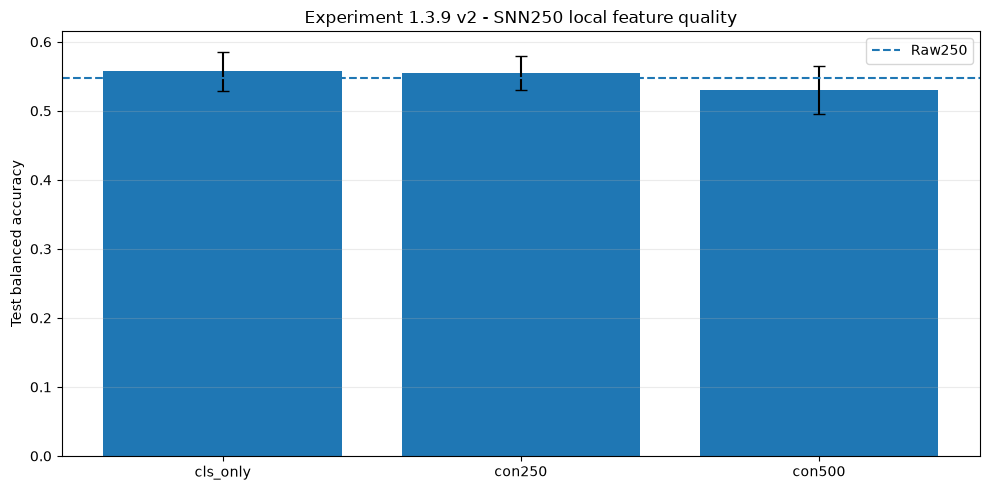

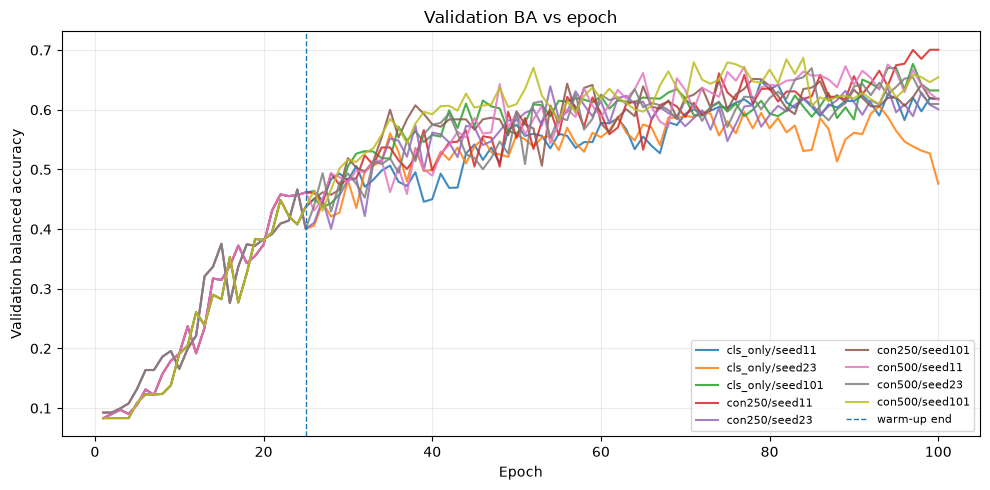

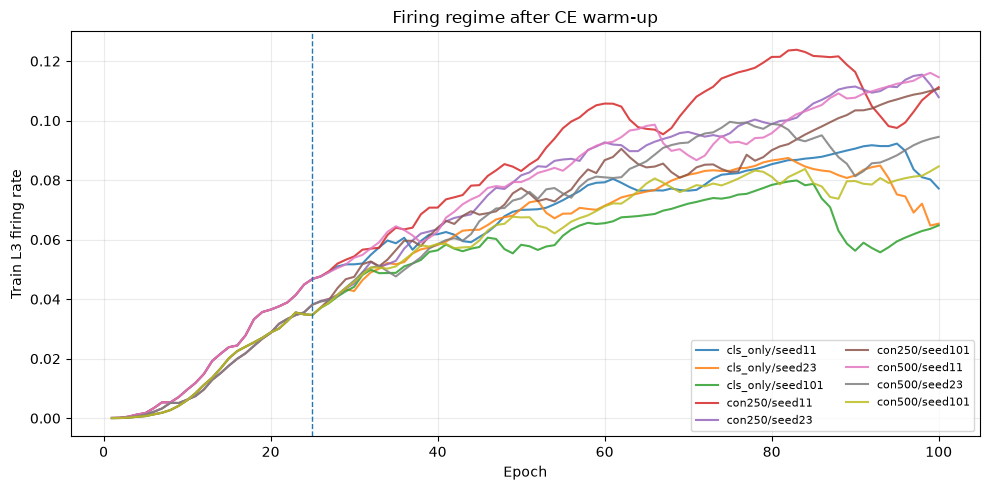

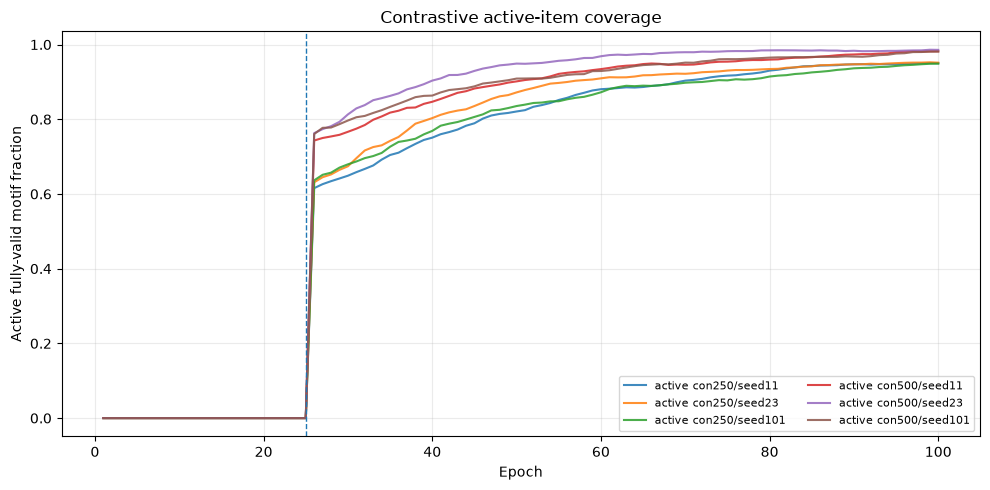

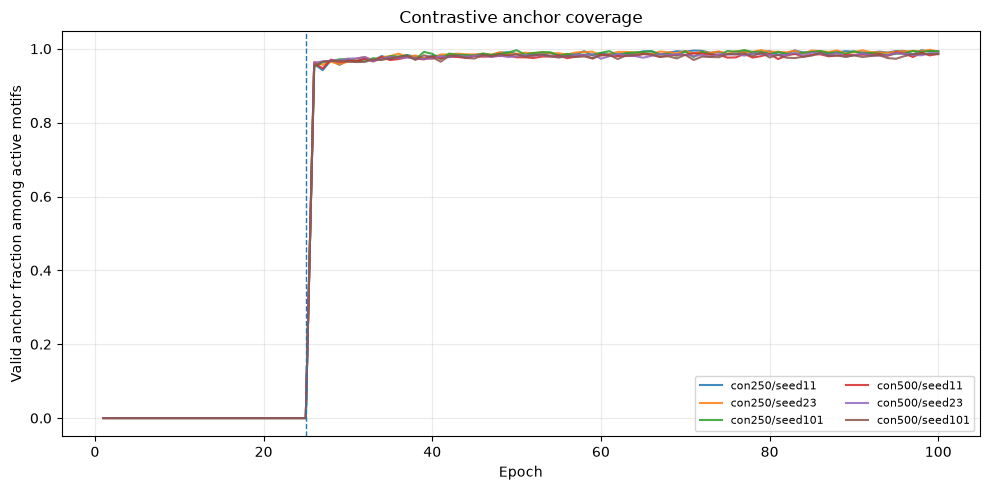

,condition,lambda_con,mean_probe_val_BA,sd_probe_val_BA,mean_global_val_BA,mean_train_l3_fr,mean_active_item_fraction,mean_valid_anchor_fraction
0,con250,0.00,0.643342,0.007588,0.643993,0.077217,0.000000,0.000000
1,con250,0.01,0.639462,0.016386,0.638746,0.080420,0.837151,0.987109
2,con250,0.03,0.653726,0.019188,0.652105,0.080339,0.850854,0.987207
3,con250,0.10,0.672608,0.063291,0.663911,0.095243,0.922705,0.994577
4,con500,0.00,0.643342,0.007588,0.643993,0.077217,0.000000,0.000000
5,con500,0.01,0.621980,0.014990,0.648049,0.079452,0.929834,0.976033
6,con500,0.03,0.646329,0.013295,0.657507,0.087537,0.942964,0.977115
7,con500,0.10,0.686795,0.024902,0.677513,0.095661,0.979033,0.981623


,representation,condition,n_runs,mean_test_BA,sd_test_BA,mean_test_accuracy,mean_test_macro_f1,mean_delta_test_BA_vs_Raw250
0,SNN125,cls_only,3,0.552579,0.031115,0.540351,0.531646,0.005622
1,SNN125,con250,3,0.547288,0.038513,0.540351,0.535985,0.000331
2,SNN125,con500,3,0.563492,0.039138,0.550877,0.544512,0.016534
3,SNN250,cls_only,3,0.557595,0.028301,0.543860,0.533675,0.010637
4,SNN250,con250,3,0.554619,0.024377,0.554386,0.538504,0.007661
5,SNN250,con500,3,0.530423,0.034727,0.533333,0.521303,-0.016534


,condition,mode,mean_SameLabel_at_1,mean_SameLabel_at_5,mean_knn5_BA,sd_knn5_BA,mean_n_queries
0,cls_only,250,0.239708,0.217883,0.236109,0.001445,3008.666667
1,cls_only,500,0.304728,0.270300,0.294423,0.010855,2724.666667
2,con250,250,0.240461,0.218727,0.244818,0.008370,3301.666667
3,con250,500,0.314577,0.278234,0.303999,0.009769,2877.333333
4,con500,250,0.239248,0.220506,0.242936,0.006553,3333.333333
5,con500,500,0.310088,0.284015,0.304948,0.007969,2891.000000


,condition,mean_snn_only_test_BA,mean_raw_plus_snn_test_BA,mean_fusion_delta_vs_raw,sd_fusion_delta_vs_raw
0,cls_only,0.557595,0.610615,0.063657,0.006570
1,con250,0.554619,0.637952,0.090994,0.047741
2,con500,0.530423,0.612269,0.065311,0.005444


Selected lambdas: {'con250': 0.1, 'con500': 0.1}
Raw250 test BA: 0.546957671957672
Saved outputs to: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_9_phase_aware_cross_user_contrastive_local_features/active_warmup_v2


In [7]:
%run -i ../scripts/experiment_1_3_9_phase_aware_contrastive/04_diagnostics.py

## Decision rules

- If a nonzero `lambda_con` beats `lambda=0` in mean validation SNN250 probe BA and retains a reasonable firing regime, phase-aware contrastive shaping is supported.
- If `con500` consistently outperforms `con250`, 250 ms features likely behave as local primitives that become class-relevant only after short temporal composition.
- If `lambda=0` wins after the warm-up/gating fix, the negative result is much stronger: class-conditioned local SupCon itself is probably mismatched to this task, rather than merely suffering from silent-vector normalization.
- Raw+SNN fusion remains diagnostic only and is never treated as the final architecture.